
--- Iteration: 100 ---
New column(s) added with minimum reduced cost: -480.0278081647416

--- Iteration: 200 ---
New column(s) added with minimum reduced cost: -75.27205347487256

--- Iteration: 300 ---
New column(s) added with minimum reduced cost: -19.338094205277457

--- Column Generation Complete ---
No more profitable columns found. Optimal LP solution reached.

--- FINAL P-MEDIAN SOLUTION ---
Selected Facilities (p=3): [18, 8, 26]
Objective value: 4774.5971343036135 meters
Facility: 18 | Clients: [4, 9, 11, 12, 18, 23, 24, 29]
Facility: 8 | Clients: [1, 3, 5, 6, 7, 8, 10, 13, 14, 17, 20, 22, 25, 27, 30]
Facility: 26 | Clients: [2, 15, 16, 19, 21, 26, 28]


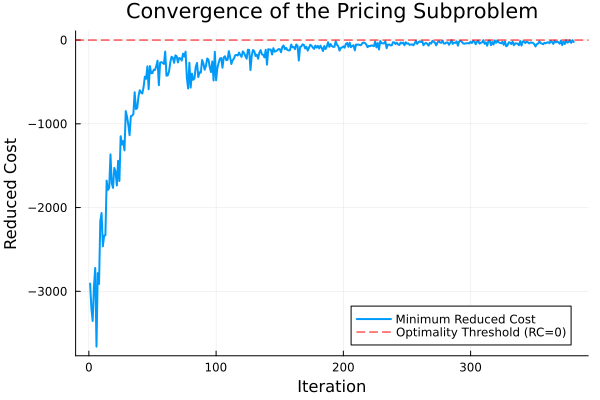

PyObject <folium.folium.Map object at 0x00000164605DDE80>

In [ ]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 6 – Graph problems
#  Section: 6.3 - Column generation for p-median
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP       # Modeling language
using HiGHS      # Solver
using CSV        # For reading CSV files
using DataFrames # For handling data frames
using Distances  # For distance calculations
using Plots      # For plotting
using Random     # For random number generation

# Utility functions for plotting solution on map
include("utils/pmp-n_utils.jl")

# Define a structure to hold column information
mutable struct Column
    cost::Float64
    median::Int64
    client_assignments::Vector{Int64}
end

# Function to read coordinates and compute Haversine distance matrix
function read_data(file_path)
    # Read the CSV file and convert it to a matrix
    coordinates = CSV.read(file_path, DataFrame) |> Matrix{Float64}

    # Compute Haversine distance matrix
    distance_matrix = Distances.pairwise(Distances.Haversine(), coordinates, dims=1)

    return coordinates, distance_matrix
end

# Function to plot the convergence of reduced costs
function plot_reduced_costs(reduced_cost_history)
    p = Plots.plot(
        1:length(reduced_cost_history), 
        reduced_cost_history,
        label="Minimum Reduced Cost",
        xlabel="Iteration",
        ylabel="Reduced Cost",
        title="Convergence of the Pricing Subproblem",
        legend=:bottomright,
        linewidth=2
    )
    # Add a horizontal line at y=0 to show the convergence target
    Plots.hline!(p, [0], linestyle=:dash, color=:red, label="Optimality Threshold (RC=0)")
    # Display the plot
    display(p)
end

# Function to create initial columns for the column generation process
function create_initial_columns(initial_columns_total, distance_matrix)
    n = size(distance_matrix, 1)
    columns = Column[]
    for id in 1:initial_columns_total
        # Ensure we don't get an empty cluster
        client_assignments = zeros(Int64, n)
        while sum(client_assignments) == 0
             client_assignments .= [rand() > 0.5 ? 1 : 0 for _ in 1:n]
        end

        # Get indices of assigned clients
        assigned_indices = findall(client_assignments .== 1)
        
        # Calculate sum of distances from each point in the cluster to all others in the cluster
        costs = [sum(distance_matrix[i, assigned_indices]) for i in assigned_indices]
        
        # Find the point with the minimum cost to be the median
        minimum_cost, idx = findmin(costs)
        median = assigned_indices[idx]
        
        push!(columns, Column(minimum_cost, median, client_assignments))
    end
    return columns
end

# Function to solve the master problem (RMP)
function master_problem(distance_matrix, p, columns; solve_as_integer=false)
    # Number of clients and columns
    n_clients = size(distance_matrix,1)
    n_columns = length(columns)
    
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Variables
    if solve_as_integer
        @variable(model, y[1:n_columns], Bin)
    else
        @variable(model, 0 <= y[1:n_columns] <= 1)
    end
    
    # Objective: Minimize the total cost of the selected columns
    @objective(model, Min, sum(y[i] * columns[i].cost for i in 1:n_columns))

    # Constraint: Each client 'j' must be served by at least one selected column
    if solve_as_integer
        @constraint(model, covering_satisfaction[j=1:n_clients], sum(columns[i].client_assignments[j] * y[i] for i in 1:n_columns) == 1)
    else
        @constraint(model, covering_satisfaction[j=1:n_clients], sum(columns[i].client_assignments[j] * y[i] for i in 1:n_columns) >= 1)
    end

    # Constraint: Ensures that exactly 'p' columns are chosen
    @constraint(model, p_median_satisfaction, sum(y) == p)

    # Solve the model
    JuMP.optimize!(model)

    # Check the results and return dual prices
    if solve_as_integer
        if JuMP.termination_status(model) == JuMP.OPTIMAL
            return nothing, nothing, JuMP.value.(y)
        else
            error("Final integer problem did not solve to optimality. Status: $(JuMP.termination_status(model))")
            return nothing, nothing, nothing
        end
    else
        if JuMP.termination_status(model) == JuMP.OPTIMAL
            π = JuMP.dual.(covering_satisfaction)
            σ = JuMP.dual(p_median_satisfaction)
            return π, σ, nothing
        else
            error("RMP was not solved to optimality. Status: $(JuMP.termination_status(model))")
        end
    end
end

# Function to solve the pricing subproblem
function sub_problem(distance_matrix, p, columns, π, σ)
    
    # Number of clients
    n_clients = size(distance_matrix,1)
    
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    
    # Variables
    @variable(model, x[1:n_clients, 1:n_clients], Bin)
    
    # Objective: Minimize the reduced cost
    @objective(model, Min, sum((distance_matrix[i,j] - π[j]) * x[i,j] for i in 1:n_clients, j in 1:n_clients) - σ)
    
    # Constraint: Exactly 'p' medians must be selected
    @constraint(model, sum(x[i,i] for i in 1:n_clients) == p)
    
    # Constraint: A client 'j' can only be assigned to a median 'i' if 'i' is selected as a median
    @constraint(model, [i=1:n_clients, j=1:n_clients], x[i,i] >= x[i,j])
    
    # Solve the model
    JuMP.optimize!(model)
    
    # Check the results
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        
        # Extract the solution
        x_sub = JuMP.value.(x)
        
        # Prepare to add new columns
        new_column_found = false
        cost = 0.0
        reduced_cost = 0.0
        minimum_reduced_cost = typemax(Float64)
        
        # Create new columns if negative reduced cost is found
        for i in 1:n_clients
            if x_sub[i,i] > 0.5
                # Calculate the cost of the new column
                reduced_cost = 0.0
                for j in 1:n_clients
                    reduced_cost += ((distance_matrix[i,j] - π[j]) * x_sub[i,j])
                end
                reduced_cost -= σ
                # Check if the reduced cost is negative
                if reduced_cost < 0.000001
                    # Store the minimum subproblem cost if found
                    minimum_reduced_cost = min(minimum_reduced_cost, reduced_cost)
                    # Create the new column
                    client_assignments = zeros(Int64, n_clients)
                    cost = 0.0
                    for k in 1:n_clients
                        client_assignments[k] = x_sub[i,k]
                        cost += (x_sub[i,k] * distance_matrix[i,k])
                    end
                    push!(columns, Column(cost, i, client_assignments))
                    new_column_found = true
                end
            end
        end
        return new_column_found, minimum_reduced_cost
    else
        error("Subproblem was not solved to optimality. Status: $(JuMP.termination_status(model))")
        return false, nothing
    end
end

# Function to solve the p-median problem using column generation
function solve_pmedian_gc(file_path; p = 3, initial_columns_total = 20, iterations = 100)

    # Vector to store reduced costs for each iteration
    reduced_cost_history = []

    # Read data and compute distance matrix
    coordinates, distance_matrix = read_data(file_path)

    # --- 1. Create initial columns ---
    columns = create_initial_columns(initial_columns_total, distance_matrix)

    # --- 2. Column generation loop ---
    for iteration in 1:iterations
        
        # --- 3. Solve the Restricted Master Problem (RMP) ---
        π, σ, _ = master_problem(distance_matrix, p, columns, solve_as_integer = false)

        # --- 4. Solve the Pricing Subproblem ---
        new_column_found, minimum_reduced_cost = sub_problem(distance_matrix, p, columns, π, σ)

        # --- 5. Check if a new pattern was found ---
        if !new_column_found || minimum_reduced_cost > -1e-6
            println("\n--- Column Generation Complete ---")
            println("No more profitable columns found. Optimal LP solution reached.")
            break
        else
            if iteration % 100 == 0
                println("\n--- Iteration: $iteration ---")
                println("New column(s) added with minimum reduced cost: $minimum_reduced_cost")
            end
            push!(reduced_cost_history, minimum_reduced_cost)
        end
    end

    # --- 6. Solve the Final Integer Problem ---
    _, _, y_values = master_problem(distance_matrix, p, columns, solve_as_integer = true)

    # --- 7. Generate reduced cost Plot ---
    plot_reduced_costs(reduced_cost_history)

    # --- 8. Post-process and display the final solution ---
    selected_column_indices = findall(y_values .> 0.5)

    println("\n--- FINAL P-MEDIAN SOLUTION ---")
    println("Selected Facilities (p=$p): $([columns[i].median for i in selected_column_indices])")
    println("Objective value: $(sum([columns[i].cost for i in selected_column_indices])) meters")
    assignments = Dict()
    for column_id in selected_column_indices
        facility = columns[column_id].median
        clients = findall(columns[column_id].client_assignments .== 1)
        assignments[facility] = clients
        println("Facility: $facility | Clients: $clients")
    end

    # Plot the final solution on the map
    plot_solution(coordinates, assignments, p)
end

# Set random seed for reproducibility
Random.seed!(42)

# Example usage
solve_pmedian_gc("data/sjc_coordinates_cg.csv", p = 3, initial_columns_total = 500, iterations = 800)